# Encuesta Continua de Hogares (ECH) - Entrega final
## Taller de Programación - UBA
## Grupo 4
---

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
from google.colab import drive
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,accuracy_score,recall_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import re
import seaborn as sns

drive.mount('/content/drive', force_remount=True)

ruta = "/content/drive/MyDrive/Taller de Programación '26/ECH"
base_implementacion_2025 = pd.read_csv(os.path.join(ruta, "ECH_2025_implantacion.csv"),low_memory=False)


Mounted at /content/drive


In [ ]:
print(base_implementacion_2025.shape)
display(base_implementacion_2025.head())



(55397, 516)


,Unnamed: 0,...1,ID,nper,anio,mes,GR,region,REGION_4,dpto,...,montoUTE_RRAA,pobre17,indig17,lp_17,li_17,pobre_multi,W_TRI,W_SEM,W_ANO,YDA
0,1,1,80790.0,1,2025,1,43,1,1,1,...,0.0,0,0,14583.835536,6309.488401,0,140,75,37,224980.000000
1,2,2,80791.0,1,2025,1,43,1,1,1,...,0.0,0,0,23702.715365,6309.488401,0,129,60,31,53833.333333
2,3,3,80792.0,1,2025,1,43,1,1,1,...,0.0,0,0,14583.835536,6309.488401,0,207,110,54,86500.000000
3,4,4,80793.0,1,2025,1,43,1,1,1,...,0.0,0,0,23702.715365,6309.488401,0,119,60,30,78000.000000
4,5,5,80794.0,1,2025,1,43,1,1,1,...,0.0,0,0,23702.715365,6309.488401,0,119,60,30,60000.000000


Levanto los archivos de seguimiento:

In [ ]:
ruta_seguimiento = os.path.join(ruta, "seguimiento")

archivos = sorted(Path(ruta_seguimiento).glob("*.csv"))

print("Archivos encontrados:")
for archivo in archivos:
    print(archivo.name)

Archivos encontrados:
ECH_06_2025.csv
ECH_07_2025.csv
ECH_08_2025.csv
ECH_09_2025.csv
ECH_10_2025.csv
ECH_11_2025.csv
ECH_12_2025.csv


In [ ]:
bases_mensuales = []

for archivo in archivos:

    df = pd.read_csv(
        archivo,
        low_memory=False,
        encoding='latin1'
    )

    # Limpieza simple de nombres
    df.columns = (
        df.columns
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )

    # Guardamos el origen
    df["archivo_origen"] = archivo.name

    bases_mensuales.append(df)

seguimientos = pd.concat(
    bases_mensuales,
    ignore_index=True
)

print("Dimensiones seguimiento:", seguimientos.shape)
display(seguimientos.head())

Dimensiones seguimiento: (133082, 140)


,Unnamed: 0,ID,nper,anio,mes,GR,ronda,region,REGION_4,dpto,...,f117,f124_1,f124_2,f124_3,f124_5,POBPCOAC,SUBEMPLEO,NIV_EDU,W,archivo_origen
0,1,82726.0,1,2025,6,44,5,1,1,1,...,0,2,2,2,1,2,0,4. Terciario completo o posgrado,222,ECH_06_2025.csv
1,2,82727.0,1,2025,6,44,5,1,1,1,...,2,2,2,2,1,7,0,3. Sec. completa o terciaria incomp,146,ECH_06_2025.csv
2,3,82728.0,1,2025,6,44,5,1,1,1,...,2,1,2,2,1,10,0,3. Sec. completa o terciaria incomp,146,ECH_06_2025.csv
3,4,82728.0,2,2025,6,44,5,1,1,1,...,2,1,1,2,2,10,0,1. CB incompleto o menos,146,ECH_06_2025.csv
4,5,82729.0,1,2025,6,44,5,1,1,1,...,0,2,2,2,1,2,0,3. Sec. completa o terciaria incomp,251,ECH_06_2025.csv


Reviso las instancias de encuesta por cada archvio:

In [ ]:
pd.crosstab(seguimientos["mes"],seguimientos["ronda"])

ronda,1,2,3,4,5,6
mes,,,,,,
6,3932,3124,2880,2919,2824,3065
7,3761,3491,3165,3040,3110,3099
8,4038,3235,3152,3039,2931,2968
9,3896,3148,2682,2705,2755,2734
10,3795,3167,3000,2725,2732,2803
11,3965,3243,3211,3167,2956,3020
12,3961,3340,3091,3146,3142,2925


Reviso los tipos de datos en las columnas clave:

In [ ]:
for df in [base_implementacion_2025, seguimientos]:

    df["ID"] = pd.to_numeric(
        df["ID"],
        errors="coerce"
    ).astype("Int64")

    df["nper"] = pd.to_numeric(
        df["nper"],
        errors="coerce"
    ).astype("Int64")

In [ ]:
print(base_implementacion_2025[["ID", "nper"]].dtypes)
print(seguimientos[["ID", "nper"]].dtypes)

ID      Int64
nper    Int64
dtype: object
ID      Int64
nper    Int64
dtype: object


Me voy a quedar unicamente con las entrevistas 6 (última entrevista): esto es para generar la transición entre la primera instancia que se entrevista a la persona y la última.

In [ ]:
seguimiento_final = (seguimientos[seguimientos["ronda"] == 6].copy())

print("Cantidad de observaciones en ronda final:")
print(len(seguimiento_final))

print("\nPor mes:")
print(
    seguimiento_final["mes"]
    .value_counts()
    .sort_index()
)

Cantidad de observaciones en ronda final:
20614

Por mes:
mes
6     3065
7     3099
8     2968
9     2734
10    2803
11    3020
12    2925
Name: count, dtype: int64


De las personas que aparecen en la implementación, unicamente nos podemos quedar con aquellos que tengan ya publicada su última encuesta de seguimieto, es decir, su implementación fue entre enero y julio (ej: quienes se implementen en agosto 2025, tendrán su encuesta final en enero 2026 y ese dato aún no está publicado). También sacamos a los menores de 14, quienes no participan de este módulo de la encuesta.

In [ ]:
implantacion_panel = (
    base_implementacion_2025[
        (base_implementacion_2025["mes"].between(1, 7)) &
        (base_implementacion_2025["e27"] >= 14)
    ]
    .copy()
)

print(
    "Personas de 14+ implantadas entre enero y julio:",
    len(implantacion_panel)
)

print("\nPor mes de implantación:")
print(
    implantacion_panel["mes"]
    .value_counts()
    .sort_index()
)

Personas de 14+ implantadas entre enero y julio: 27944

Por mes de implantación:
mes
1    4106
2    4073
3    4103
4    4026
5    3943
6    3932
7    3761
Name: count, dtype: int64


Reviso que no existan duplicados en las bases:

In [ ]:
print("Duplicados implantación:",implantacion_panel.duplicated(["ID", "nper"]).sum())
print("Duplicados seguimiento final:",seguimiento_final.duplicated(["ID", "nper"]).sum())

Duplicados implantación: 0
Duplicados seguimiento final: 0


In [ ]:
panel = implantacion_panel.merge(
    seguimiento_final,
    on=["ID", "nper"],
    how="left",
    suffixes=("_t0", "_t5"),
    indicator=True,
    validate="one_to_one"
)

print(
    panel["_merge"]
    .value_counts()
)

_merge
both          20080
left_only      7864
right_only        0
Name: count, dtype: int64


Aquí es clave que la diferencia tiene que ser 5 pues:

 *t* = implementación

 *t+5* = último seguimiento para esa persona.

In [ ]:
panel["diferencia_meses"] = (
    panel["anio_t5"] * 12
    + panel["mes_t5"]
    - panel["anio_t0"] * 12
    - panel["mes_t0"]
)

print(
    panel.loc[
        panel["_merge"] == "both",
        "diferencia_meses"
    ]
    .value_counts()
    .sort_index()
)

diferencia_meses
5.0    20080
Name: count, dtype: int64


In [ ]:
panel_match = panel[
    panel["_merge"] == "both"
].copy()

tabla_meses = pd.crosstab(
    panel_match["mes_t0"],
    panel_match["mes_t5"]
)

display(tabla_meses)

mes_t5,6.0,7.0,8.0,9.0,10.0,11.0,12.0
mes_t0,,,,,,,
1,2967,0,0,0,0,0,0
2,0,3005,0,0,0,0,0
3,0,0,2886,0,0,0,0
4,0,0,0,2680,0,0,0
5,0,0,0,0,2733,0,0
6,0,0,0,0,0,2959,0
7,0,0,0,0,0,0,2850


Tasa de emparejamiento individual entre implantación y ronda 6:

In [ ]:
tasa_match = (panel["_merge"].eq("both").mean() * 100)

print(f"Porcentaje observado hasta ronda 6: {tasa_match:.2f}%")

Porcentaje observado hasta ronda 6: 71.86%


Revisión de la atrición: verificamos que no se generen diferencias importantes entre los grupos.

In [ ]:
# Indicador de permanencia hasta ronda 6
panel["observado_t5"] = (panel["_merge"] == "both").astype(int)

# Algunas características observadas en t0
vars_attrition = [
    "e26_t0",       # sexo
    "e27_t0",       # edad
    "region_t0",
    "POBPCOAC_t0"
]

for var in vars_attrition:
    print(f"\n--- {var} ---")

    display(
        panel.groupby("observado_t5")[var]
        .value_counts(normalize=True)
        .unstack()
        .round(3)
    )


--- e26_t0 ---


e26_t0,1,2
observado_t5,,
0,0.470,0.530
1,0.461,0.539



--- e27_t0 ---


e27_t0,14,15,16,17,18,19,20,21,22,23,...,94,95,96,97,98,99,100,101,102,104
observado_t5,,,,,,,,,,,,,,,,,,,,,
0,0.016,0.020,0.018,0.020,0.020,0.016,0.017,0.017,0.019,0.015,...,0.001,0.001,0.001,0.0,0.001,0.0,0.0,0.0,NaN,NaN
1,0.015,0.015,0.017,0.015,0.015,0.015,0.015,0.014,0.013,0.013,...,0.001,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0



--- region_t0 ---


region_t0,1,2,3
observado_t5,,,
0,0.407,0.432,0.161
1,0.374,0.446,0.180



--- POBPCOAC_t0 ---


POBPCOAC_t0,2,3,4,5,6,7,8,9,10,11
observado_t5,,,,,,,,,,
0,0.536,0.011,0.051,0.002,0.063,0.094,0.004,0.056,0.173,0.010
1,0.542,0.008,0.032,0.003,0.059,0.089,0.004,0.047,0.208,0.007


In [ ]:
panel.groupby("observado_t5")["e27_t0"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
observado_t5,,,,
0,7864,46.33,46.0,20.60
1,20080,48.47,49.0,20.14


No encontramos diferencias sustanciales en las principales características observables entre quienes permanecen y quienes salen del panel.

## Genero los work status

In [ ]:
variables_status = [
    "POBPCOAC",
    "f73",
    "f77",
    "f82",
    "f305",
    "f306",
    "NIV_EDU",
    "e26",
    "e27",
    "f72_2"
]

disponibilidad = pd.DataFrame({
    "variable": variables_status,
    "implantacion_t0": [
        var in implantacion_panel.columns
        for var in variables_status
    ],
    "seguimiento_t5": [
        var in seguimiento_final.columns
        for var in variables_status
    ]
})

display(disponibilidad)



,variable,implantacion_t0,seguimiento_t5
0,POBPCOAC,True,True
1,f73,True,True
2,f77,True,False
3,f82,True,True
4,f305,True,True
5,f306,True,True
6,NIV_EDU,False,True
7,e26,True,True
8,e27,True,True
9,f72_2,True,True


In [ ]:
print("Variables relacionadas con tamaño/empresa en implantación:")
print([
    c for c in implantacion_panel.columns
    if "77" in c.lower() or "305" in c.lower() or "306" in c.lower()
])

print("\nVariables relacionadas con tamaño/empresa en seguimiento:")
print([
    c for c in seguimiento_final.columns
    if "77" in c.lower() or "305" in c.lower() or "306" in c.lower()
])

Variables relacionadas con tamaño/empresa en implantación:
['f277', 'f77', 'f305', 'f306']

Variables relacionadas con tamaño/empresa en seguimiento:
['f277', 'f305', 'f306']


In [ ]:
variables_a_revisar = [
    "POBPCOAC",
    "f73",
    "f77",
    "f82",
    "f305",
    "f306",
    "NIV_EDU",
    "e26",
    "e27",
    "f72_2",
    "region"
]

for var in variables_a_revisar:

    print(f"\n--- {var} ---")

    print(
        "Implantación:",
        var in implantacion_panel.columns
    )

    print(
        "Seguimiento:",
        var in seguimiento_final.columns
    )

    if var in implantacion_panel.columns:
        print("Valores t0:")
        print(
            implantacion_panel[var]
            .value_counts(dropna=False)
            .head(15)
        )

    if var in seguimiento_final.columns:
        print("Valores t5:")
        print(
            seguimiento_final[var]
            .value_counts(dropna=False)
            .head(15)
        )


--- POBPCOAC ---
Implantación: True
Seguimiento: True
Valores t0:
POBPCOAC
2     15096
10     5548
7      2532
6      1682
9      1381
4      1055
3       243
11      212
8       117
5        78
Name: count, dtype: int64
Valores t5:
POBPCOAC
2     11326
10     4305
7      1904
6      1178
9       924
4       531
3       196
11      156
8        57
5        37
Name: count, dtype: int64

--- f73 ---
Implantación: True
Seguimiento: True
Valores t0:
f73
0    12848
1     8163
9     3980
2     2264
4      520
7      100
3       42
8       27
Name: count, dtype: int64
Valores t5:
f73
0.0    9290
1.0    5946
9.0    3032
2.0    1792
4.0     420
7.0      79
8.0      33
3.0      21
NaN       1
Name: count, dtype: int64

--- f77 ---
Implantación: True
Seguimiento: False
Valores t0:
f77
0    12848
9     4216
1     3943
2     2282
3     1109
4     1106
5     1073
7      762
8      605
Name: count, dtype: int64

--- f82 ---
Implantación: True
Seguimiento: True
Valores t0:
f82
0    12848
1    11463
2

Usamos la relación observada en implantación entre naturaleza jurídica (f305) y tamaño (f77) para aproximar el tamaño cuando f77 deja de observarse.

In [ ]:
# VALIDACIÓN DE LA PROXY DE TAMAÑO / ESTRUCTURA EN t0

implantacion_panel["tamano_claro"] = pd.Series(
    pd.NA,
    index=implantacion_panel.index,
    dtype="string"
)

# Claramente pequeñas respecto al corte del paper:
# 1 persona / 2 a 4 personas
implantacion_panel.loc[
    implantacion_panel["f77"].isin([1, 2]),
    "tamano_claro"
] = "Pequena"

# Claramente grandes:
# 10 o más personas
implantacion_panel.loc[
    implantacion_panel["f77"].isin([4, 5, 7, 8, 9]),
    "tamano_claro"
] = "Grande"

# f77 = 3 corresponde a 5-9 personas.
# No puede asignarse de forma inequívoca al corte <=5 / >5
# utilizado por Maurizio y Monsalvo, por lo que se excluye
# únicamente de esta validación.

In [ ]:
etiquetas_f305 = {
    1: "Empresa unipersonal",
    2: "Sociedad de hecho / civil",
    3: "Sociedad anonima",
    4: "SRL / sociedad con contrato",
    5: "Cooperativa",
    6: "Otra",
    7: "No tributa",
    8: "No sabe"
}

In [ ]:
validacion_proxy = implantacion_panel[
    (implantacion_panel["POBPCOAC"] == 2) &
    (implantacion_panel["f73"] != 2) &  # excluye asalariados públicos
    (implantacion_panel["tamano_claro"].notna()) &
    (implantacion_panel["f305"].isin(etiquetas_f305.keys()))
].copy()

validacion_proxy["f305_nombre"] = (
    validacion_proxy["f305"]
    .map(etiquetas_f305)
)

In [ ]:
tabla_n = pd.crosstab(
    validacion_proxy["f305_nombre"],
    validacion_proxy["tamano_claro"]
)

tabla_pct = pd.crosstab(
    validacion_proxy["f305_nombre"],
    validacion_proxy["tamano_claro"],
    normalize="index"
) * 100

print("Cantidad de casos:")
display(tabla_n)

print("\nDistribución porcentual:")
display(tabla_pct.round(1))

Cantidad de casos:


tamano_claro,Grande,Pequena
f305_nombre,,
Cooperativa,168,7
Empresa unipersonal,11,1907
No sabe,3079,1049
No tributa,18,2819
Otra,145,168
SRL / sociedad con contrato,358,112
Sociedad anonima,1511,94
Sociedad de hecho / civil,184,69



Distribución porcentual:


tamano_claro,Grande,Pequena
f305_nombre,,
Cooperativa,96.0,4.0
Empresa unipersonal,0.6,99.4
No sabe,74.6,25.4
No tributa,0.6,99.4
Otra,46.3,53.7
SRL / sociedad con contrato,76.2,23.8
Sociedad anonima,94.1,5.9
Sociedad de hecho / civil,72.7,27.3


In [ ]:
# A partir de la relación observada entre f305 y tamaño de empresa en t0,
# aproximamos si la unidad económica es pequeña (0) o grande/estructurada (1).

mapa_estructura = {
    1: 0,  # Empresa unipersonal
    2: 1,  # Sociedad de hecho / civil
    3: 1,  # Sociedad anónima
    4: 1,  # SRL / sociedad con contrato
    5: 1,  # Cooperativa
    7: 0,  # No tributa
    8: 1   # No sabe: empíricamente asociado a empresa grande
}

implantacion_panel["unidad_estructurada"] = (
    implantacion_panel["f305"].map(mapa_estructura)
)

seguimiento_final["unidad_estructurada"] = (
    seguimiento_final["f305"].map(mapa_estructura)
)

In [ ]:
# Trabajador profesional:
# completó algún nivel terciario

implantacion_panel["profesional"] = (
    (implantacion_panel["e215_1"] == 1) |
    (implantacion_panel["e218_1"] == 1) |
    (implantacion_panel["e221_1"] == 1) |
    (implantacion_panel["e224_1"] == 1)
).astype(int)

seguimiento_final["profesional"] = (
    (seguimiento_final["e215_1"] == 1) |
    (seguimiento_final["e218_1"] == 1) |
    (seguimiento_final["e221_1"] == 1) |
    (seguimiento_final["e224_1"] == 1)
).astype(int)

In [ ]:
for base in [implantacion_panel, seguimiento_final]:

    base["work_status5"] = pd.Series(
        pd.NA,
        index=base.index,
        dtype="string"
    )

    # 1. Asalariado formal
    base.loc[
        (base["POBPCOAC"] == 2) &
        (base["f73"].isin([1, 2])) &
        (base["f82"] == 1),
        "work_status5"
    ] = "Formal wage"

    # 2. Asalariado informal upper-tier
    base.loc[
        (base["POBPCOAC"] == 2) &
        (base["f73"] == 1) &
        (base["f82"] == 2) &
        (base["unidad_estructurada"] == 1),
        "work_status5"
    ] = "Upper-tier informal wage"

    # 3. Asalariado informal lower-tier
    base.loc[
        (base["POBPCOAC"] == 2) &
        (base["f73"] == 1) &
        (base["f82"] == 2) &
        (base["unidad_estructurada"] == 0),
        "work_status5"
    ] = "Lower-tier informal wage"

    # 4. Independiente formal
    base.loc[
        (base["POBPCOAC"] == 2) &
        (
            ((base["f73"] == 4) &
             (base["unidad_estructurada"] == 1))
            |
            ((base["f73"] == 9) &
             (base["profesional"] == 1))
        ),
        "work_status5"
    ] = "Formal self-employed"

    # 5. Independiente informal
    base.loc[
        (base["POBPCOAC"] == 2) &
        (
            ((base["f73"] == 4) &
             (base["unidad_estructurada"] == 0))
            |
            ((base["f73"] == 9) &
             (base["profesional"] == 0))
            |
            (base["f73"] == 7)
        ),
        "work_status5"
    ] = "Informal self-employed"

In [ ]:
print("Implantación:")
display(
    implantacion_panel["work_status5"]
    .value_counts(dropna=False)
    .to_frame("personas")
)

print("\nSeguimiento final:")
display(
    seguimiento_final["work_status5"]
    .value_counts(dropna=False)
    .to_frame("personas")
)

Implantación:


,personas
work_status5,
<NA>,12951
Formal wage,9385
Informal self-employed,3721
Formal self-employed,853
Upper-tier informal wage,620
Lower-tier informal wage,414



Seguimiento final:


,personas
work_status5,
<NA>,9377
Formal wage,7037
Informal self-employed,2830
Formal self-employed,674
Lower-tier informal wage,392
Upper-tier informal wage,304


In [ ]:
print("Ocupados sin work status en t0:")
display(
    implantacion_panel.loc[
        (implantacion_panel["POBPCOAC"] == 2) &
        (implantacion_panel["work_status5"].isna()),
        ["f73", "f82", "f305", "unidad_estructurada"]
    ].value_counts(dropna=False)
)

print("\nOcupados sin work status en t5:")
display(
    seguimiento_final.loc[
        (seguimiento_final["POBPCOAC"] == 2) &
        (seguimiento_final["work_status5"].isna()),
        ["f73", "f82", "f305", "unidad_estructurada"]
    ].value_counts(dropna=False)
)

Ocupados sin work status en t0:


,,,,count
f73,f82,f305,unidad_estructurada,
3,1,5,1.0,34
4,1,6,NaN,25
8,1,0,NaN,23
1,2,6,NaN,7
3,1,1,0.0,2
8,1,2,1.0,2
3,1,4,1.0,1
2,2,0,NaN,1
3,2,4,1.0,1



Ocupados sin work status en t5:


f73  f82  f305  unidad_estructurada
8.0  1    0     NaN                    31
4.0  1    6     NaN                    26
3.0  1    5     1.0                    11
2.0  2    0     NaN                     3
3.0  1    1     0.0                     3
          8     1.0                     3
1.0  2    6     NaN                     2
0.0  2    6     NaN                     1
          7     0.0                     1
3.0  1    4     1.0                     1
          3     1.0                     1
          2     1.0                     1
          6     NaN                     1
4.0  2    6     NaN                     1
8.0  1    8     1.0                     1
     2    0     NaN                     1
NaN  1    8     1.0                     1
Name: count, dtype: int64

## Genero la base para el modelado

In [ ]:
panel_modelo = implantacion_panel.merge(
    seguimiento_final[
        ["ID", "nper", "POBPCOAC", "work_status5"]
    ],
    on=["ID", "nper"],
    how="inner",
    suffixes=("_t0", "_t5"),
    validate="one_to_one"
)

print(panel_modelo.shape)

(20080, 522)


In [ ]:
panel_modelo["estado_t0"] = panel_modelo["work_status5_t0"]
panel_modelo["estado_t5"] = panel_modelo["work_status5_t5"]

# Desocupados
panel_modelo.loc[
    panel_modelo["POBPCOAC_t0"].isin([3, 4, 5]),
    "estado_t0"
] = "Unemployed"

panel_modelo.loc[
    panel_modelo["POBPCOAC_t5"].isin([3, 4, 5]),
    "estado_t5"
] = "Unemployed"

# Inactivos
panel_modelo.loc[
    panel_modelo["POBPCOAC_t0"].isin([6, 7, 8, 9, 10, 11]),
    "estado_t0"
] = "Inactive"

panel_modelo.loc[
    panel_modelo["POBPCOAC_t5"].isin([6, 7, 8, 9, 10, 11]),
    "estado_t5"
] = "Inactive"

In [ ]:
panel_matriz = panel_modelo.dropna(
    subset=["estado_t0", "estado_t5"]
).copy()

print(
    "Observaciones utilizadas en la matriz:",
    len(panel_matriz)
)

Observaciones utilizadas en la matriz: 19977


In [ ]:
matriz_transicion = pd.crosstab(
    panel_matriz["estado_t0"],
    panel_matriz["estado_t5"],
    normalize="index"
) * 100

display(matriz_transicion.round(1))

estado_t5,Formal self-employed,Formal wage,Inactive,Informal self-employed,Lower-tier informal wage,Unemployed,Upper-tier informal wage
estado_t0,,,,,,,
Formal self-employed,92.6,1.1,1.7,3.9,0.0,0.8,0.0
Formal wage,0.2,94.7,1.8,0.8,0.6,1.3,0.7
Inactive,0.1,1.2,93.3,1.9,0.5,2.9,0.2
Informal self-employed,0.7,1.5,3.5,92.3,0.3,1.5,0.2
Lower-tier informal wage,0.0,11.4,7.9,3.5,61.4,6.3,9.4
Unemployed,0.6,15.9,25.2,12.6,4.9,37.5,3.3
Upper-tier informal wage,0.3,15.2,5.9,4.1,22.7,7.0,44.8


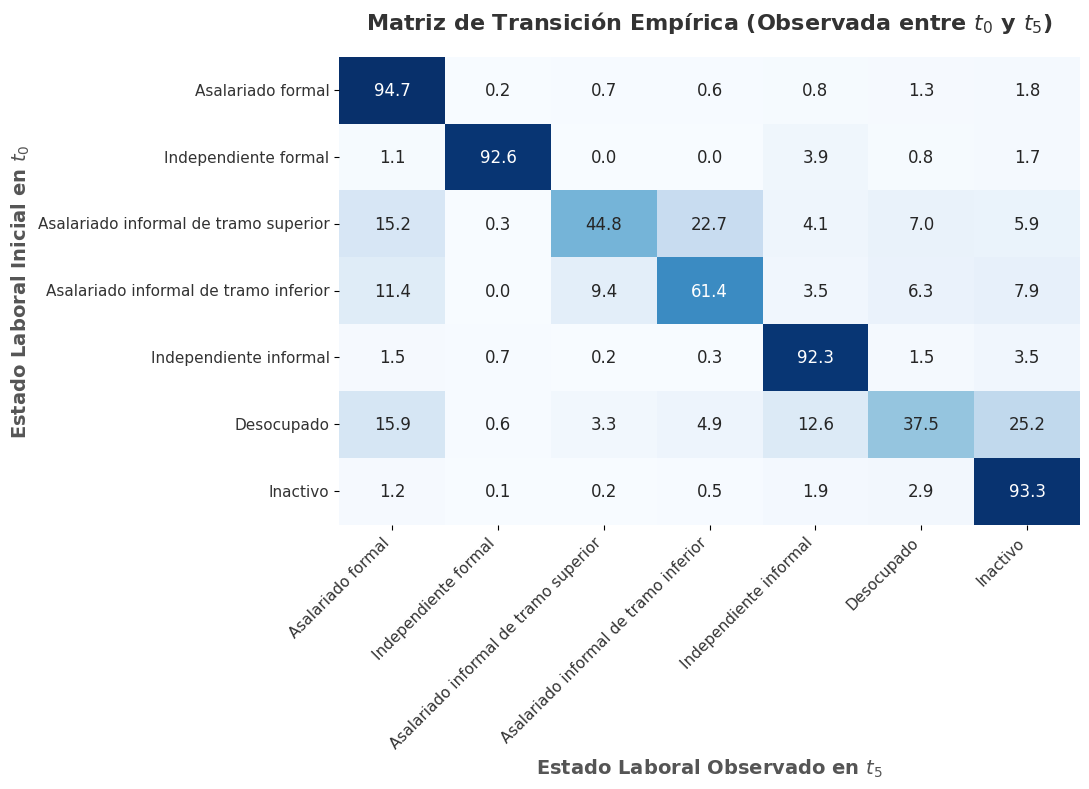

In [ ]:
# Traducción de las etiquetas de status laboral (mismo mapeo usado en las matrices anteriores)
etiquetas_es = {
    "Formal wage": "Asalariado formal",
    "Formal self-employed": "Independiente formal",
    "Upper-tier informal wage": "Asalariado informal de tramo superior",
    "Lower-tier informal wage": "Asalariado informal de tramo inferior",
    "Informal self-employed": "Independiente informal",
    "Unemployed": "Desocupado",
    "Inactive": "Inactivo"
}

# Orden deseado (en español), tomado del orden de las claves del diccionario
orden_es = list(etiquetas_es.values())

# Traducimos y reordenamos filas y columnas
matriz_transicion_es = (
    matriz_transicion
    .rename(index=etiquetas_es, columns=etiquetas_es)
    .reindex(index=orden_es, columns=orden_es)
)

# Configuramos el tamaño de la figura
fig, ax = plt.subplots(figsize=(11, 8))

# Generamos el heatmap usando la matriz traducida y reordenada
sns.heatmap(
    matriz_transicion_es,
    annot=True,
    fmt=".1f",           # Sin signo %
    cmap="Blues",
    cbar=False,
    ax=ax,
    annot_kws={"size": 12} # Números internos en tamaño 12 (corregido)
)

# Formato estético unificado
ax.set_title('Matriz de Transición Empírica (Observada entre $t_0$ y $t_5$)',
             fontsize=16, fontweight='bold', color='#333333', pad=20)
ax.set_xlabel('Estado Laboral Observado en $t_5$', fontsize=14, fontweight='bold', color='#555555')
ax.set_ylabel('Estado Laboral Inicial en $t_0$', fontsize=14, fontweight='bold', color='#555555')

plt.xticks(rotation=45, ha='right', fontsize=11, color='#333333')
plt.yticks(rotation=0, fontsize=11, color='#333333')

plt.tight_layout()
plt.show()

In [ ]:
variables_modelo = [
    "estado_t0",
    "e26",       # sexo
    "e27",       # edad
    "region"
]

base_clasificacion = panel_matriz[
    variables_modelo + ["estado_t5"]
].dropna().copy()

print("Observaciones para el modelo:", len(base_clasificacion))

display(
    base_clasificacion["estado_t5"]
    .value_counts()
    .to_frame("personas")
)



Observaciones para el modelo: 19977


,personas
estado_t5,
Inactive,8249
Formal wage,6890
Informal self-employed,2772
Unemployed,735
Formal self-employed,660
Lower-tier informal wage,379
Upper-tier informal wage,292


In [ ]:
# Variables explicativas
X = base_clasificacion[
    variables_modelo
].copy()

# Creamos dummies para las variables categóricas
X = pd.get_dummies(
    X,
    columns=[
        "estado_t0",
        "e26",
        "region"
    ],
    drop_first=True,
    dtype=int
)

# Estandarizamos edad
X["e27"] = (
    (X["e27"] - X["e27"].mean()) /
    X["e27"].std()
)

X = X.astype(float)
# Aseguramos formato numérico
X = X.astype(float)

print(X.shape)
display(X.head())

(19977, 10)


,e27,estado_t0_Formal wage,estado_t0_Inactive,estado_t0_Informal self-employed,estado_t0_Lower-tier informal wage,estado_t0_Unemployed,estado_t0_Upper-tier informal wage,e26_2,region_2,region_3
0,1.017521,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.414213,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.818687,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.024651,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.520923,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
y = base_clasificacion["estado_t5"]

In [ ]:
orden_estados = [
    "Formal wage",
    "Upper-tier informal wage",
    "Lower-tier informal wage",
    "Formal self-employed",
    "Informal self-employed",
    "Unemployed",
    "Inactive"
]

## Modelo Logit

In [ ]:
# 1. Separamos la muestra en Entrenamiento (80%) y Testeo (20%)
# Usamos stratify=y para mantener la proporción de los estados laborales en ambas particiones
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

print("Dimensiones de Entrenamiento (Train):", X_train.shape)
print("Dimensiones de Testeo (Test):", X_test.shape)

# 2. Entrenamos el modelo Logit Multinomial SÓLO con los datos de Train
logit_model = LogisticRegression(
    penalty=None,
    max_iter=2000
)

logit_model.fit(X_train, y_train)

# 3. Predecimos AFUERA de la muestra (sobre los datos de Test)
estado_predicho_test = logit_model.predict(X_test)

Dimensiones de Entrenamiento (Train): (15981, 10)
Dimensiones de Testeo (Test): (3996, 10)


Gráfico de probabilidades predichas de estado laboral por edad

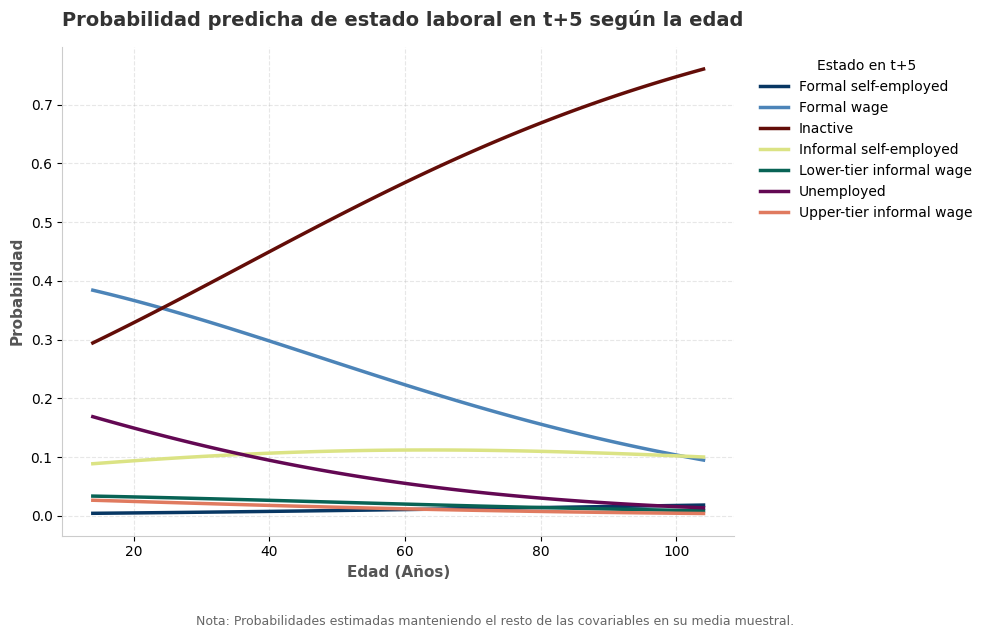

In [ ]:
# Recuperamos la media y el desvío originales de la base antes de ser estandarizada
media_edad = base_clasificacion['e27'].mean()
std_edad = base_clasificacion['e27'].std()

# Generamos el rango de edades reales observadas (ej: de 14 a 85 años)
edad_real_min = base_clasificacion['e27'].min()
edad_real_max = base_clasificacion['e27'].max()
edades_reales = np.linspace(edad_real_min, edad_real_max, 100)

# Estandarizamos este rango solo para pasarlo por el modelo predictivo
edades_estandarizadas = (edades_reales - media_edad) / std_edad

# Creamos un DataFrame copiando la estructura de predictores de entrenamiento
X_simulado = pd.DataFrame(index=range(100), columns=X_train.columns)

# Mantenemos todas las variables en su valor promedio (Ceteris Paribus)
for col in X_train.columns:
    X_simulado[col] = X_train[col].mean()

# Reemplazamos la columna de edad con nuestra simulación estandarizada
X_simulado['e27'] = edades_estandarizadas

# Predecimos las probabilidades
probabilidades_simuladas = logit_model.predict_proba(X_simulado)
df_probs = pd.DataFrame(probabilidades_simuladas, columns=logit_model.classes_)

# Usamos la edad real para el eje X
df_probs['Edad_Real'] = edades_reales

fig, ax = plt.subplots(figsize=(10, 6))

# Paleta de alto contraste basada en tus muestras complementarias
colores_distintivos = [
    '#083763', # Azul oscuro (Base)
    '#4C84B8', # Azul claro
    '#630D08', # Rojo oscuro
    '#DBE384', # Verde amarillento claro (Alto contraste)
    '#086355', # Verde esmeralda/Teal
    '#630853', # Púrpura
    '#E07A5F'  # Naranja coral (Contraste cálido extra)
]

for i, estado in enumerate(logit_model.classes_):
    ax.plot(
        df_probs['Edad_Real'],
        df_probs[estado],
        label=estado,
        linewidth=2.5,
        color=colores_distintivos[i % len(colores_distintivos)]
    )

ax.set_title('Probabilidad predicha de estado laboral en t+5 según la edad',
             fontsize=14, fontweight='bold',  color="#333333", loc='left', pad=15)
ax.set_xlabel('Edad (Años)', color='#555555', fontsize=11, fontweight='bold')
ax.set_ylabel('Probabilidad', color='#555555', fontsize=11, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='both', linestyle='--', alpha=0.3)

ax.legend(title='Estado en t+5', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.text(0.5, -0.05, 'Nota: Probabilidades estimadas manteniendo el resto de las covariables en su media muestral.',
         ha='center', fontsize=9, color='#666666')

plt.tight_layout()
plt.show()

Estimación con Statsmodels para obtener errores estándar:

Se replica la especificación del logit multinomial utilizando
Statsmodels con el objetivo de obtener errores estándar,
significancia estadística e intervalos de confianza de los coeficientes.

In [ ]:
y_sm = pd.Categorical(
    base_clasificacion["estado_t5"],
    categories=orden_estados
).codes

# Mismo conjunto de predictores utilizado en sklearn
X_sm = X.copy()

# Statsmodels necesita que agreguemos explícitamente la constante
X_sm = sm.add_constant(X_sm)

modelo_sm = sm.MNLogit(
    y_sm,
    X_sm
)

resultado_sm = modelo_sm.fit(
    method="bfgs",
    maxiter=500,
    disp=False
)

print(resultado_sm.summary())

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                19977
Model:                        MNLogit   Df Residuals:                    19911
Method:                           MLE   Df Model:                           60
Date:                Wed, 09 Sep 2026   Pseudo R-squ.:                  0.7077
Time:                        06:12:43   Log-Likelihood:                -8043.6
converged:                       True   LL-Null:                       -27520.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -3.7281      1.949     -1.913      0.056      -7.548       0.092
e27                                   -0.1012      0.096   

In [ ]:
print("Convergió:",resultado_sm.mle_retvals["converged"])
print("Cantidad de coeficientes NaN:",resultado_sm.params.isna().sum().sum())

Convergió: True
Cantidad de coeficientes NaN: 0


In [ ]:
tablas_resultados = []

for j, columna in enumerate(resultado_sm.params.columns):

    destino = orden_estados[j + 1]

    tabla = pd.DataFrame({
        "Variable": resultado_sm.params.index,
        "Coeficiente": resultado_sm.params[columna].values,
        "Error estándar": resultado_sm.bse[columna].values,
        "p-value": resultado_sm.pvalues[columna].values,
        "RRR": np.exp(
            resultado_sm.params[columna].values
        )
    })

    tabla["Comparación"] = (
        destino + " vs " + orden_estados[0]
    )

    tablas_resultados.append(tabla)


tabla_resultados = pd.concat(
    tablas_resultados,
    ignore_index=True
)

display(
    tabla_resultados.round(3)
)

,Variable,Coeficiente,Error estándar,p-value,RRR,Comparación
0,const,-3.728,1.949,0.056,0.024,Upper-tier informal wage vs Formal wage
1,e27,-0.101,0.096,0.292,0.904,Upper-tier informal wage vs Formal wage
2,estado_t0_Formal wage,-1.982,1.949,0.309,0.138,Upper-tier informal wage vs Formal wage
3,estado_t0_Inactive,1.158,1.962,0.555,3.185,Upper-tier informal wage vs Formal wage
4,estado_t0_Informal self-employed,0.944,2.002,0.637,2.571,Upper-tier informal wage vs Formal wage
...,...,...,...,...,...,...
61,estado_t0_Unemployed,0.046,0.523,0.930,1.047,Inactive vs Formal wage
62,estado_t0_Upper-tier informal wage,-1.564,0.567,0.006,0.209,Inactive vs Formal wage
63,e26_2,0.087,0.091,0.339,1.091,Inactive vs Formal wage
64,region_2,0.077,0.099,0.441,1.080,Inactive vs Formal wage


In [ ]:
output_file_path = os.path.join(ruta, "resultados_modelo_logit.csv")

tabla_resultados.to_csv(output_file_path, index=False, encoding='utf-8')

print(f"Tabla de resultados guardada exitosamente en: {output_file_path}")

Tabla de resultados guardada exitosamente en: /content/drive/MyDrive/Taller de Programación '26/ECH/resultados_modelo_logit.csv


In [ ]:
prob_logit = logit_model.predict_proba(X)

In [ ]:
prob_logit = pd.DataFrame(
    prob_logit,
    columns=logit_model.classes_,
    index=base_clasificacion.index
)

display(prob_logit.head())

,Formal self-employed,Formal wage,Inactive,Informal self-employed,Lower-tier informal wage,Unemployed,Upper-tier informal wage
0,0.001567,0.007545,0.967172,0.008595,0.001890,0.012758,0.000474
1,0.001075,0.024577,0.877579,0.012238,0.006009,0.076480,0.002042
2,0.001056,0.962422,0.011225,0.004838,0.004580,0.012069,0.003809
3,0.001815,0.953735,0.019277,0.004822,0.004253,0.013254,0.002844
4,0.948419,0.008274,0.010991,0.021753,0.002076,0.007103,0.001384


In [ ]:
display(prob_logit.sum(axis=1).describe())

,0
count,1.997700e+04
mean,1.000000e+00
std,1.649699e-16
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [ ]:
estado_predicho_logit = logit_model.predict(X)

In [ ]:
pd.Series(estado_predicho_logit).value_counts()

,count
Inactive,8536
Formal wage,6903
Informal self-employed,2599
Formal self-employed,665
Unemployed,643
Upper-tier informal wage,377
Lower-tier informal wage,254


## Matriz de confusión

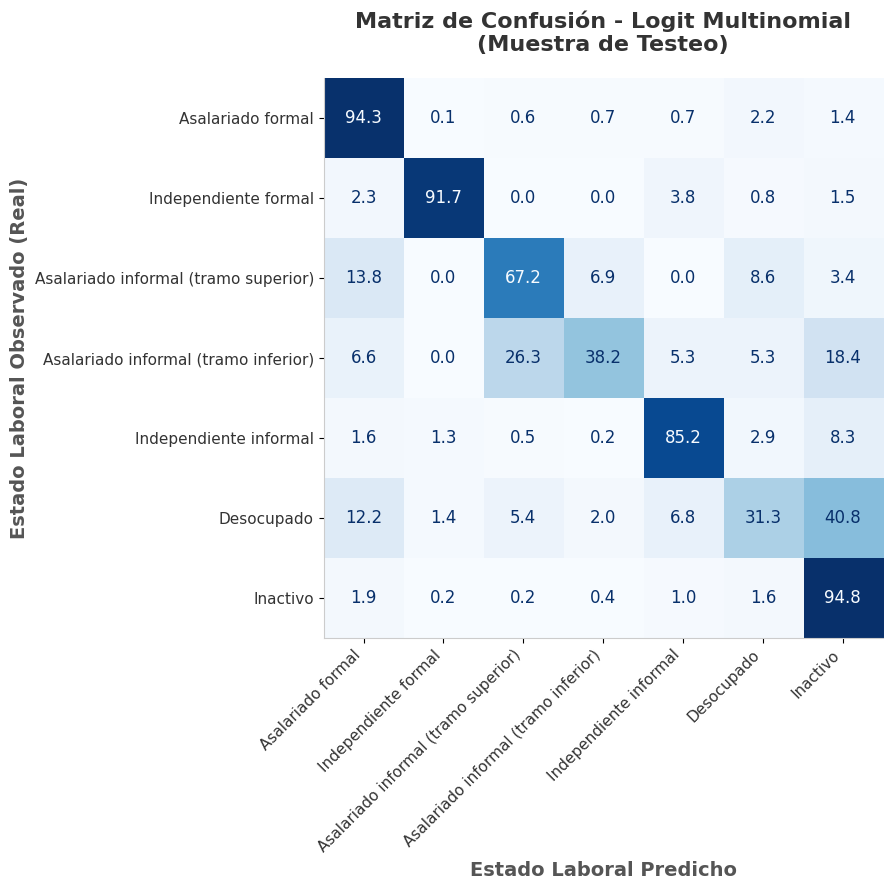

In [ ]:
# Traducción de las etiquetas de status laboral (mismo mapeo usado en la matriz de transición)
etiquetas_es = {
    "Formal wage": "Asalariado formal",
    "Formal self-employed": "Independiente formal",
    "Upper-tier informal wage": "Asalariado informal (tramo superior)",
    "Lower-tier informal wage": "Asalariado informal (tramo inferior)",
    "Informal self-employed": "Independiente informal",
    "Unemployed": "Desocupado",
    "Inactive": "Inactivo"
}

# Orden deseado, en inglés (nombres reales de las clases del modelo)
orden_en = list(etiquetas_es.keys())

# Traducimos ese mismo orden para mostrarlo en el gráfico
etiquetas_traducidas = [etiquetas_es[clase] for clase in orden_en]

# Calculamos la matriz normalizada respetando el orden deseado, y la MULTIPLICAMOS POR 100
cm_test = confusion_matrix(
    y_test,
    estado_predicho_test,
    labels=orden_en,
    normalize='true'
) * 100

fig, ax = plt.subplots(figsize=(11, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=etiquetas_traducidas
)

# Usamos .1f en lugar de .1% para eliminar el símbolo, e igualamos el tamaño de fuente interna
disp.plot(
    cmap='Blues',
    values_format='.1f',
    text_kw={'size': 12}, # Igualamos el tamaño de los números a 12
    ax=ax,
    colorbar=False
)

# Formato estético 100% igualado a la matriz anterior
ax.set_title('Matriz de Confusión - Logit Multinomial\n(Muestra de Testeo)',
             fontsize=16, fontweight='bold', color='#333333', pad=20)
ax.set_xlabel('Estado Laboral Predicho', fontsize=14, fontweight='bold', color='#555555')
ax.set_ylabel('Estado Laboral Observado (Real)', fontsize=14, fontweight='bold', color='#555555')

plt.xticks(rotation=45, ha='right', fontsize=11, color='#333333')
plt.yticks(fontsize=11, color='#333333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluamos el desempeño predictivo real
accuracy_logit = accuracy_score(y_test, estado_predicho_test)
recall_logit = recall_score(y_test, estado_predicho_test, average="macro")

print(f"\nAccuracy Logit (Test): {accuracy_logit:.3f}")
print(f"Recall promedio Logit (Test): {recall_logit:.3f}")


Accuracy Logit (Test): 0.894
Recall promedio Logit (Test): 0.718


## Comparación

In [ ]:
# Estado más probable según la matriz de transición
estado_mas_probable = matriz_transicion.idxmax(axis=1)

# Clasificación usando solamente el estado inicial (evaluado sobre y_test para consistencia)
pred_matriz_test = base_clasificacion.loc[y_test.index, "estado_t0"].map(estado_mas_probable)

accuracy_matriz = accuracy_score(y_test, pred_matriz_test)
recall_matriz = recall_score(y_test, pred_matriz_test, average="macro")

# Tabla comparativa base (Funciona de forma autónoma)
comparacion = pd.DataFrame({
    "Modelo": [
        "Matriz de transición",
        "Logit multinomial"
    ],
    "Accuracy": [
        accuracy_matriz,
        accuracy_logit
    ],
    "Recall promedio": [
        recall_matriz,
        recall_logit
    ]
})

display(comparacion.round(3))

,Modelo,Accuracy,Recall promedio
0,Matriz de transición,0.892,0.728
1,Logit multinomial,0.894,0.718


In [ ]:
prob_con_estado = prob_logit.copy()
prob_con_estado["estado_t0"] = base_clasificacion["estado_t0"]

matriz_logit = (
    prob_con_estado
    .groupby("estado_t0")
    .mean() * 100
)

# Mismo orden que la matriz observada
matriz_logit = matriz_logit.reindex(
    index=matriz_transicion.index,
    columns=matriz_transicion.columns
)

print("Matriz de transición implícita del Logit:")
display(matriz_logit.round(1))

diferencia_matrices = matriz_logit - matriz_transicion
print("\nDiferencia entre Matriz Logit y Matriz Histórica:")
display(diferencia_matrices.round(1))

Matriz de transición implícita del Logit:


estado_t5,Formal self-employed,Formal wage,Inactive,Informal self-employed,Lower-tier informal wage,Unemployed,Upper-tier informal wage
estado_t0,,,,,,,
Formal self-employed,93.2,0.7,1.1,3.9,0.3,0.5,0.3
Formal wage,0.1,94.7,1.7,0.8,0.7,1.3,0.7
Inactive,0.1,1.2,93.3,1.8,0.5,2.8,0.2
Informal self-employed,0.6,1.3,3.6,92.6,0.2,1.4,0.2
Lower-tier informal wage,0.1,9.9,7.2,3.8,63.0,6.5,9.5
Unemployed,0.7,14.7,25.7,12.1,5.0,38.7,3.1
Upper-tier informal wage,0.2,16.7,6.4,4.3,22.0,6.3,44.2



Diferencia entre Matriz Logit y Matriz Histórica:


estado_t5,Formal self-employed,Formal wage,Inactive,Informal self-employed,Lower-tier informal wage,Unemployed,Upper-tier informal wage
estado_t0,,,,,,,
Formal self-employed,0.5,-0.3,-0.5,-0.0,0.3,-0.2,0.3
Formal wage,-0.0,0.0,-0.1,0.0,0.1,-0.0,0.0
Inactive,0.0,0.1,0.0,-0.1,-0.0,-0.0,0.0
Informal self-employed,-0.1,-0.1,0.1,0.3,-0.1,-0.1,0.0
Lower-tier informal wage,0.1,-1.6,-0.6,0.3,1.6,0.2,0.1
Unemployed,0.1,-1.2,0.5,-0.5,0.1,1.2,-0.2
Upper-tier informal wage,-0.1,1.5,0.4,0.1,-0.7,-0.6,-0.7


Comparación de métodos: CART

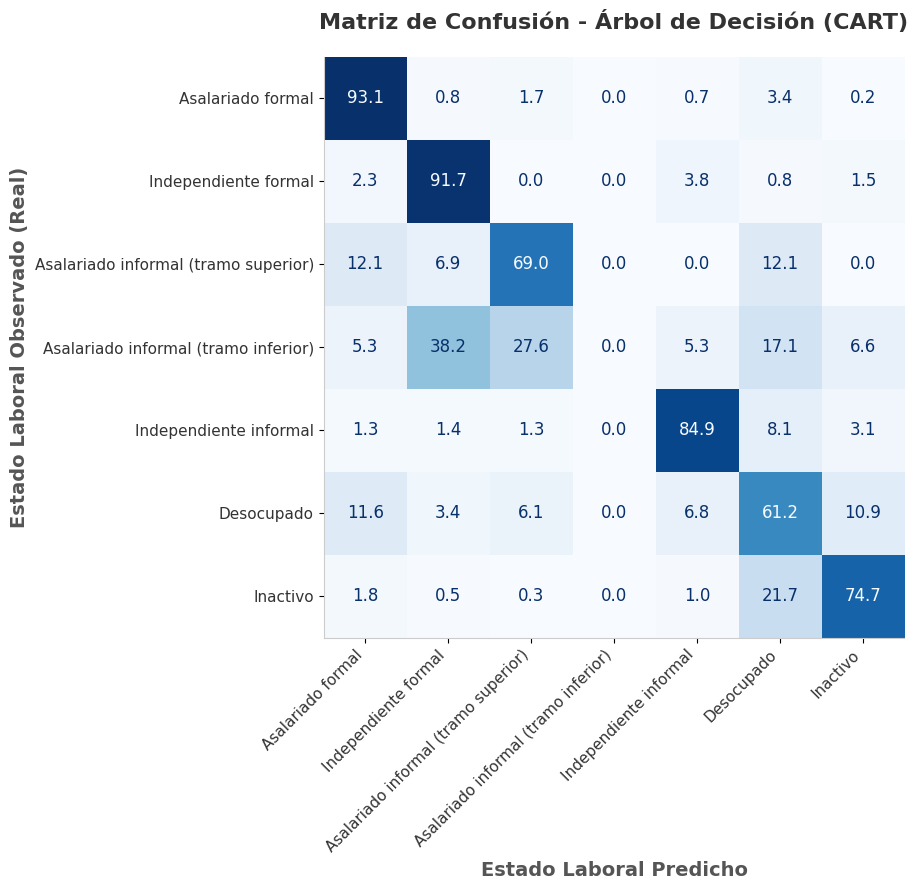

In [ ]:
# Traducción de las etiquetas de status laboral (mismo mapeo usado en las matrices anteriores)
etiquetas_es = {
    "Formal wage": "Asalariado formal",
    "Formal self-employed": "Independiente formal",
    "Upper-tier informal wage": "Asalariado informal (tramo superior)",
    "Lower-tier informal wage": "Asalariado informal (tramo inferior)",
    "Informal self-employed": "Independiente informal",
    "Unemployed": "Desocupado",
    "Inactive": "Inactivo"
}

# Orden deseado, en inglés (nombres reales de las clases del modelo)
orden_en = list(etiquetas_es.keys())

# Traducimos ese mismo orden para mostrarlo en el gráfico
etiquetas_traducidas = [etiquetas_es[clase] for clase in orden_en]

# 1. Entrenamos el Árbol de Decisión (CART)
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    random_state=123,
    class_weight='balanced'
)
modelo_arbol.fit(X_train, y_train)

# Predicción del Árbol sobre los datos de Testeo
pred_arbol_test = modelo_arbol.predict(X_test)

# 2. Calculamos la matriz de confusión normalizada respetando el orden deseado, y la multiplicamos por 100
cm_arbol = confusion_matrix(
    y_test,
    pred_arbol_test,
    labels=orden_en,
    normalize='true'
) * 100

# 3. Preparamos el gráfico individual (tamaño igualado al Logit)
fig, ax = plt.subplots(figsize=(11, 9))

disp_arbol = ConfusionMatrixDisplay(
    confusion_matrix=cm_arbol,
    display_labels=etiquetas_traducidas
)

# Quitamos el % e igualamos el tamaño de los números a 12
disp_arbol.plot(
    cmap='Blues',
    values_format='.1f',
    text_kw={'size': 12},
    ax=ax,
    colorbar=False
)

# Formato estético idéntico a las otras matrices
ax.set_title('Matriz de Confusión - Árbol de Decisión (CART)',
             fontsize=16, fontweight='bold', color='#333333', pad=20)
ax.set_xlabel('Estado Laboral Predicho', fontsize=14, fontweight='bold', color='#555555')
ax.set_ylabel('Estado Laboral Observado (Real)', fontsize=14, fontweight='bold', color='#555555')

plt.xticks(rotation=45, ha='right', fontsize=11, color='#333333')
plt.yticks(fontsize=11, color='#333333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluación oficial out-of-sample sobre el conjunto de Testeo
accuracy_arbol = accuracy_score(y_test, pred_arbol_test)
recall_arbol = recall_score(y_test, pred_arbol_test, average="macro")

print(f"Accuracy Árbol (Test): {accuracy_arbol:.3f}")
print(f"Recall promedio Árbol (Test): {recall_arbol:.3f}")

Accuracy Árbol (Test): 0.810
Recall promedio Árbol (Test): 0.678


Tabla Comparativa Final de Modelos (Out-of-Sample)

In [ ]:
# Estado más probable según la matriz de transición
estado_mas_probable = matriz_transicion.idxmax(axis=1)

# Clasificación usando la Matriz de Transición evaluada SOBRE Y_TEST (consistencia metodológica)
pred_matriz_test = base_clasificacion.loc[y_test.index, "estado_t0"].map(estado_mas_probable)

accuracy_matriz = accuracy_score(y_test, pred_matriz_test)
recall_matriz = recall_score(y_test, pred_matriz_test, average="macro")

comparacion = pd.DataFrame({
    "Modelo": [
        "Matriz de transición",
        "Logit multinomial",
        "Árbol de decisión (CART)"
    ],
    "Accuracy": [
        accuracy_matriz,
        accuracy_logit,
        accuracy_arbol
    ],
    "Recall promedio": [
        recall_matriz,
        recall_logit,
        recall_arbol
    ]
})

display(comparacion.round(3))

,Modelo,Accuracy,Recall promedio
0,Matriz de transición,0.892,0.728
1,Logit multinomial,0.894,0.718
2,Árbol de decisión (CART),0.810,0.678
